# 05 - Hyperparameter Tuning

## Objectives
- Optimize hyperparameters for best performing models
- Use GridSearchCV and RandomizedSearchCV
- Use original training set (2178 samples) for consistency
- Keep all features (no reduction) to preserve performance
- Compare tuned vs baseline performance
- Select final model for deployment

## 5.1 Setup and Imports

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import time
import joblib
import json
from pathlib import Path
from typing import Dict, Any, List, Tuple

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, StratifiedKFold,
    cross_val_score
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

In [42]:
sys.path.append('..')

In [43]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## 5.2 Load Data (Original Training Set Only)

In [44]:
data_dir = Path('../data/processed')

# Load the EXACT same splits used in baseline (04_baseline_models.ipynb)
X_train = pd.read_csv(data_dir / 'X_train_full.csv')
y_train = pd.read_csv(data_dir / 'y_train_full.csv').values.ravel()
X_val = pd.read_csv(data_dir / 'X_val_full.csv')
y_val = pd.read_csv(data_dir / 'y_val_full.csv').values.ravel()
X_test = pd.read_csv(data_dir / 'X_test_full.csv')
y_test = pd.read_csv(data_dir / 'y_test_full.csv').values.ravel()

print(f"Original split (used in baseline):")
print(f"  Train: {X_train.shape[0]} samples")
print(f"  Val:   {X_val.shape[0]} samples")
print(f"  Test:  {X_test.shape[0]} samples")
print(f"  Total features: {X_train.shape[1]}")
print(f"  Dropout rate: {y_train.mean()*100:.1f}%")
print()

# Check for failed_units features
failed_features = [c for c in X_train.columns if 'failed_units' in c.lower()]
if failed_features:
    print(f"+ failed_units features present: {failed_features}")
else:
    print(f"- No failed_units features - running on original 47 features")
print()

print(f"Tuning on original training set only ({X_train.shape[0]} samples)")

# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Original split (used in baseline):
  Train: 2178 samples
  Val:   726 samples
  Test:  726 samples
  Total features: 51
  Dropout rate: 39.2%

+ failed_units features present: ['failed_units_sem1', 'failed_units_sem2', 'failed_units_total']

Tuning on original training set only (2178 samples)


## 5.3 Hyperparameter Tuning (All Features, Original Train Set)

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Cross-validation: 5-fold stratified")
print(f"Training samples per fold: ~{X_train.shape[0] * 0.8:.0f}")

Cross-validation: 5-fold stratified
Training samples per fold: ~1742


### 5.3.1 Logistic Regression Tuning

Note: we use 'lbfgs' here because using 'saga' previously, we obtain best Result was L2 (Ridge) with l1_ratio=0.0, using 'lbfgs', we have the same result faster and without convergence warnings.

In [46]:
print("--- Logistic Regression ---")

lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
    'class_weight': [None, 'balanced']
}

lr_grid = GridSearchCV(
    LogisticRegression(
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    ),
    lr_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

start = time.time()
lr_grid.fit(X_train_scaled, y_train)
lr_time = time.time() - start

print(f"Tuned in {lr_time:.1f}s")
print(f"    Best params: {lr_grid.best_params_}")
print(f"    Best CV ROC-AUC: {lr_grid.best_score_:.4f}")
print(f"    Regularization: L2 (Ridge)")

--- Logistic Regression ---
Tuned in 2.8s
    Best params: {'C': 0.1, 'class_weight': 'balanced'}
    Best CV ROC-AUC: 0.9487
    Regularization: L2 (Ridge)


### 5.3.2 Random Forest Tuning

In [47]:
print("--- Random Forest ---")
rf_param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

start = time.time()
rf_random.fit(X_train, y_train)
rf_time = time.time() - start

print(f"Tuned in {rf_time:.1f}s")
print(f"    Best params: {rf_random.best_params_}")
print(f"    Best CV ROC-AUC: {rf_random.best_score_:.4f}")

--- Random Forest ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Tuned in 23.0s
    Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced_subsample'}
    Best CV ROC-AUC: 0.9504


### 5.3.3 XGBoost Tuning

In [48]:
print("--- XGBoost ---")
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1.0, 2.0]
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_weight,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    xgb_param_dist,
    n_iter=25,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

start = time.time()
xgb_random.fit(X_train, y_train)
xgb_time = time.time() - start

print(f"Tuned in {xgb_time:.1f}s")
print(f"    Best params: {xgb_random.best_params_}")
print(f"    Best CV ROC-AUC: {xgb_random.best_score_:.4f}")

--- XGBoost ---
Fitting 5 folds for each of 25 candidates, totalling 125 fits


/Users/adrienkt/DataspellProjects/student-dropout-classifier/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:50:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/adrienkt/DataspellProjects/student-dropout-classifier/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:50:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/adrienkt/DataspellProjects/student-dropout-classifier/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:50:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/adrienkt/DataspellProjects/student-dropout-classifier/.venv/lib/python3.14/sit

Tuned in 5.9s
    Best params: {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.7}
    Best CV ROC-AUC: 0.9535


## 5.4 Random Seed Sensitivity Analysis

In [49]:
print("=" * 70)
print("RANDOM SEED SENSITIVITY")
print("=" * 70)
print()

seeds = [42, 123, 456, 789, 1024]
seed_results = []

for seed in seeds:
    lr = LogisticRegression(**lr_grid.best_params_, max_iter=2000, random_state=seed)
    lr.fit(X_train_scaled, y_train)
    lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
    
    rf = RandomForestClassifier(**rf_random.best_params_, random_state=seed, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
    
    xgb = XGBClassifier(**xgb_random.best_params_, random_state=seed, n_jobs=-1)
    xgb.fit(X_train, y_train)
    xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
    
    seed_results.append({
        'Seed': seed,
        'Logistic Regression': lr_auc,
        'Random Forest': rf_auc,
        'XGBoost': xgb_auc
    })

seed_df = pd.DataFrame(seed_results).set_index('Seed')
print("ROC-AUC across different random seeds:")
print(seed_df.round(4).to_string())
print()
print(f"Mean ± Std:")
for col in seed_df.columns:
    std_pct = seed_df[col].std() * 100
    stability = '+ Very stable' if std_pct < 0.5 else ('! Moderate' if std_pct < 1.0 else '- Unstable')
    print(f"    {col:<25s}: {seed_df[col].mean():.4f} ± {seed_df[col].std():.4f} ({stability})")

RANDOM SEED SENSITIVITY

ROC-AUC across different random seeds:
      Logistic Regression  Random Forest  XGBoost
Seed                                             
42                 0.9746         0.9746   0.9764
123                0.9746         0.9738   0.9737
456                0.9746         0.9722   0.9745
789                0.9746         0.9736   0.9732
1024               0.9746         0.9734   0.9754

Mean ± Std:
    Logistic Regression      : 0.9746 ± 0.0000 (+ Very stable)
    Random Forest            : 0.9735 ± 0.0009 (+ Very stable)
    XGBoost                  : 0.9746 ± 0.0013 (+ Very stable)


## 5.5 Evaluate Tuned Models on Test Set

In [50]:
print("=" * 70)
print("FINAL TEST SET EVALUATION")
print("=" * 70)
print()

tuned_results = {}

# Logistic Regression
lr_best = lr_grid.best_estimator_
lr_proba = lr_best.predict_proba(X_test_scaled)[:, 1]
lr_pred = lr_best.predict(X_test_scaled)
tuned_results['Logistic Regression (Tuned)'] = {
    'Accuracy': accuracy_score(y_test, lr_pred),
    'Precision': precision_score(y_test, lr_pred),
    'Recall': recall_score(y_test, lr_pred),
    'F1-Score': f1_score(y_test, lr_pred),
    'ROC-AUC': roc_auc_score(y_test, lr_proba),
    'proba': lr_proba, 'pred': lr_pred, 'model': lr_best
}

# Random Forest
rf_best = rf_random.best_estimator_
rf_proba = rf_best.predict_proba(X_test)[:, 1]
rf_pred = rf_best.predict(X_test)
tuned_results['Random Forest (Tuned)'] = {
    'Accuracy': accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred),
    'Recall': recall_score(y_test, rf_pred),
    'F1-Score': f1_score(y_test, rf_pred),
    'ROC-AUC': roc_auc_score(y_test, rf_proba),
    'proba': rf_proba, 'pred': rf_pred, 'model': rf_best
}

# XGBoost
xgb_best = xgb_random.best_estimator_
xgb_proba = xgb_best.predict_proba(X_test)[:, 1]
xgb_pred = xgb_best.predict(X_test)
tuned_results['XGBoost (Tuned)'] = {
    'Accuracy': accuracy_score(y_test, xgb_pred),
    'Precision': precision_score(y_test, xgb_pred),
    'Recall': recall_score(y_test, xgb_pred),
    'F1-Score': f1_score(y_test, xgb_pred),
    'ROC-AUC': roc_auc_score(y_test, xgb_proba),
    'proba': xgb_proba, 'pred': xgb_pred, 'model': xgb_best
}

print("Tuned Model Performance:")
print("-" * 85)
print(f"{'Model':<30s} {'Accuracy':>8s} {'Precision':>10s} {'Recall':>8s} {'F1':>8s} {'ROC-AUC':>8s}")
print("-" * 85)
for name, metrics in tuned_results.items():
    print(f"{name:<30s} {metrics['Accuracy']:>8.4f} {metrics['Precision']:>10.4f} "
          f"{metrics['Recall']:>8.4f} {metrics['F1-Score']:>8.4f} {metrics['ROC-AUC']:>8.4f}")

FINAL TEST SET EVALUATION

Tuned Model Performance:
-------------------------------------------------------------------------------------
Model                          Accuracy  Precision   Recall       F1  ROC-AUC
-------------------------------------------------------------------------------------
Logistic Regression (Tuned)      0.9242     0.8804   0.9331   0.9060   0.9746
Random Forest (Tuned)            0.9298     0.9088   0.9120   0.9104   0.9746
XGBoost (Tuned)                  0.9311     0.9007   0.9261   0.9132   0.9743


## 5.6 Compare with Baseline

In [51]:
print("=" * 70)
print("BASELINE vs TUNED COMPARISON")
print("=" * 70)
print()

baseline_results = {
    'Logistic Regression': {'ROC-AUC': 0.9749, 'F1': 0.9017},
    'Random Forest': {'ROC-AUC': 0.9723, 'F1': 0.8969},
    'XGBoost': {'ROC-AUC': 0.9743, 'F1': 0.9113}
}

print(f"{'Model':<30s} {'Metric':<10s} {'Baseline':>10s} {'Tuned':>10s} {'Change':>10s}")
print("-" * 75)
for name, metrics in tuned_results.items():
    base_name = name.replace(' (Tuned)', '')
    if base_name in baseline_results:
        for metric, metric_key in [('ROC-AUC', 'ROC-AUC'), ('F1', 'F1-Score')]:
            base_val = baseline_results[base_name].get(
                'ROC-AUC' if metric == 'ROC-AUC' else 'F1'
            )
            tuned_val = metrics[metric_key]
            change = (tuned_val - base_val) * 100
            symbol = '[UP]' if change > 0.1 else ('[DOWN]' if change < -0.1 else '[-]')
            print(f"{name:<30s} {metric:<10s} {base_val:>10.4f} {tuned_val:>10.4f} {change:>+9.2f}% {symbol}")

BASELINE vs TUNED COMPARISON

Model                          Metric       Baseline      Tuned     Change
---------------------------------------------------------------------------
Logistic Regression (Tuned)    ROC-AUC        0.9749     0.9746     -0.03% [-]
Logistic Regression (Tuned)    F1             0.9017     0.9060     +0.43% [UP]
Random Forest (Tuned)          ROC-AUC        0.9723     0.9746     +0.23% [UP]
Random Forest (Tuned)          F1             0.8969     0.9104     +1.35% [UP]
XGBoost (Tuned)                ROC-AUC        0.9743     0.9743     +0.00% [-]
XGBoost (Tuned)                F1             0.9113     0.9132     +0.19% [UP]


## 5.7 Threshold Optimization

In [52]:
print("=" * 70)
print("THRESHOLD OPTIMIZATION")
print("=" * 70)
print()

best_model_name = max(tuned_results, key=lambda k: tuned_results[k]['F1-Score'])
best_proba = tuned_results[best_model_name]['proba']
print(f"Optimizing threshold for: {best_model_name}")

thresholds = np.arange(0.10, 0.90, 0.02)
threshold_metrics = []

for thresh in thresholds:
    pred = (best_proba >= thresh).astype(int)
    threshold_metrics.append({
        'Threshold': thresh,
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
        'Accuracy': accuracy_score(y_test, pred)
    })

thresh_df = pd.DataFrame(threshold_metrics)
optimal_f1 = thresh_df.loc[thresh_df['F1'].idxmax()]
optimal_balanced = thresh_df.loc[(thresh_df['Precision'] - thresh_df['Recall']).abs().idxmin()]

print()
print(f"Optimal Thresholds:")
print(f"    For maximum F1:      {optimal_f1['Threshold']:.2f} "
      f"(F1={optimal_f1['F1']:.4f}, P={optimal_f1['Precision']:.4f}, R={optimal_f1['Recall']:.4f})")
print(f"    For balanced P/R:    {optimal_balanced['Threshold']:.2f} "
      f"(F1={optimal_balanced['F1']:.4f}, P={optimal_balanced['Precision']:.4f}, R={optimal_balanced['Recall']:.4f})")

THRESHOLD OPTIMIZATION

Optimizing threshold for: XGBoost (Tuned)

Optimal Thresholds:
    For maximum F1:      0.62 (F1=0.9231, P=0.9382, R=0.9085)
    For balanced P/R:    0.56 (F1=0.9155, P=0.9155, R=0.9155)


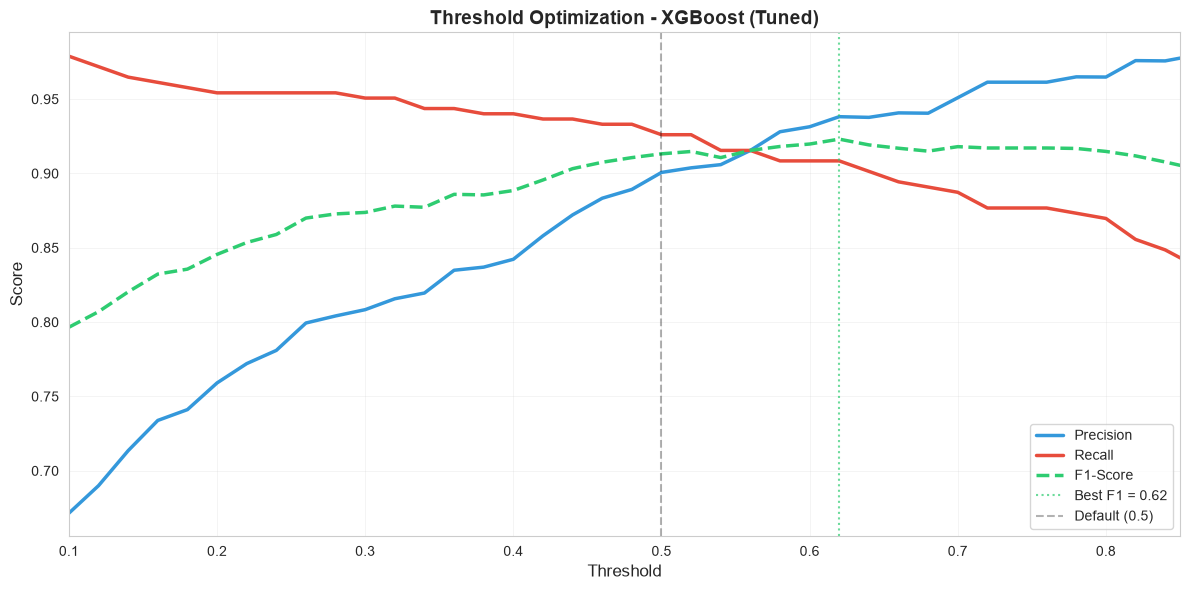

In [53]:
fig, ax = plt.subplots(figsize=(12.0, 6.0))
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], linewidth=2.5, color='#3498db', label='Precision')
ax.plot(thresh_df['Threshold'], thresh_df['Recall'], linewidth=2.5, color='#e74c3c', label='Recall')
ax.plot(thresh_df['Threshold'], thresh_df['F1'], linewidth=2.5, color='#2ecc71', label='F1-Score', linestyle='--')
ax.axvline(x=optimal_f1['Threshold'], color='#2ecc71', linestyle=':', alpha=0.7, label=f"Best F1 = {optimal_f1['Threshold']:.2f}")
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.3, label='Default (0.5)')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Threshold Optimization - {best_model_name}', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0.1, 0.85)
plt.tight_layout()
plt.savefig('../reports/figures/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.8 Early Intervention Model

In [54]:
print("=" * 70)
print("EARLY INTERVENTION MODEL")
print("=" * 70)
print()

X_train_early = pd.read_csv(data_dir / 'X_train_early.csv')
y_train_early = pd.read_csv(data_dir / 'y_train_early.csv').values.ravel()
X_test_early = pd.read_csv(data_dir / 'X_test_early.csv')
y_test_early = pd.read_csv(data_dir / 'y_test_early.csv').values.ravel()

print(f"Early features: {X_train_early.shape[1]} (vs {X_train.shape[1]} in full model)")

scaler_early = StandardScaler()
X_train_early_scaled = scaler_early.fit_transform(X_train_early)
X_test_early_scaled = scaler_early.transform(X_test_early)

scale_w = (y_train_early == 0).sum() / (y_train_early == 1).sum()

early_models = {
    'Logistic Regression': LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_w, random_state=42)
}

early_results = {}
for name, model in early_models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_early_scaled, y_train_early)
        pred = model.predict(X_test_early_scaled)
        proba = model.predict_proba(X_test_early_scaled)[:, 1]
    else:
        model.fit(X_train_early, y_train_early)
        pred = model.predict(X_test_early)
        proba = model.predict_proba(X_test_early)[:, 1]
    
    early_results[name] = {
        'Accuracy': accuracy_score(y_test_early, pred),
        'Precision': precision_score(y_test_early, pred),
        'Recall': recall_score(y_test_early, pred),
        'F1-Score': f1_score(y_test_early, pred),
        'ROC-AUC': roc_auc_score(y_test_early, proba)
    }

print()
print("Early Intervention Performance:")
print("-" * 80)
print(f"{'Model':<25s} {'Accuracy':>8s} {'Precision':>10s} {'Recall':>8s} {'F1':>8s} {'ROC-AUC':>8s}")
print("-" * 80)
for name, metrics in early_results.items():
    print(f"{name:<25s} {metrics['Accuracy']:>8.4f} {metrics['Precision']:>10.4f} "
          f"{metrics['Recall']:>8.4f} {metrics['F1-Score']:>8.4f} {metrics['ROC-AUC']:>8.4f}")

EARLY INTERVENTION MODEL

Early features: 40 (vs 51 in full model)

Early Intervention Performance:
--------------------------------------------------------------------------------
Model                     Accuracy  Precision   Recall       F1  ROC-AUC
--------------------------------------------------------------------------------
Logistic Regression         0.8939     0.8508   0.8838   0.8670   0.9474
Random Forest               0.8939     0.8532   0.8803   0.8666   0.9465
XGBoost                     0.8939     0.8606   0.8697   0.8651   0.9471


## 5.9 Model Interpretation - Logistic Regression Coefficients

In [55]:
print("=" * 70)
print("LOGISTIC REGRESSION COEFFICIENTS")
print("=" * 70)
print()

feature_names = X_train.columns.tolist()
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_best.coef_[0]
}).sort_values('Coefficient', ascending=False)

coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

print("Top 10 Risk Factors:")
print("-" * 65)
for _, row in coef_df.head(10).iterrows():
    marker = '[NEW]' if 'failed_units' in row['Feature'].lower() else '  '
    print(f"{marker} {row['Feature']:<45s} | {row['Coefficient']:+.4f} (odds: {row['Odds_Ratio']:.2f}x)")

print("\nTop 10 Protective Factors:")
print("-" * 65)
for _, row in coef_df.tail(10).iterrows():
    marker = '[NEW]' if 'failed_units' in row['Feature'].lower() else '  '
    print(f"{marker} {row['Feature']:<45s} | {row['Coefficient']:+.4f} (odds: {row['Odds_Ratio']:.2f}x)")

# FAILED_UNITS VERIFICATION
print("\n" + "-" * 65)
print("FAILED_UNITS VERIFICATION:")
failed_coeffs = coef_df[coef_df['Feature'].str.contains('failed_units', case=False)]
enrolled_coeffs = coef_df[coef_df['Feature'].str.contains('enrolled', case=False)]

if len(failed_coeffs) > 0:
    for _, row in failed_coeffs.iterrows():
        status = "+ CORRECT (risk factor)" if row['Coefficient'] > 0 else "- UNEXPECTED"
        print(f"    {row['Feature']:<40s} = {row['Coefficient']:+.4f} → {status}")
    print()
    print(f"'Enrolled' coefficients after fix:")
    for _, row in enrolled_coeffs.iterrows():
        print(f"    {row['Feature']:<40s} = {row['Coefficient']:+.4f}")
else:
    print("!!! No failed_units features found!")
    print("  'Enrolled' may still appear as a risk factor (multicollinearity artifact)")

LOGISTIC REGRESSION COEFFICIENTS

Top 10 Risk Factors:
-----------------------------------------------------------------
[NEW] failed_units_sem2                             | +0.6969 (odds: 2.01x)
[NEW] failed_units_total                            | +0.6225 (odds: 1.86x)
[NEW] failed_units_sem1                             | +0.4969 (odds: 1.64x)
   financial_stress                              | +0.4148 (odds: 1.51x)
   Course                                        | +0.4095 (odds: 1.51x)
   evaluation_intensity_sem1                     | +0.2871 (odds: 1.33x)
   disengagement_sem1                            | +0.2816 (odds: 1.33x)
   Curricular units 2nd sem (evaluations)        | +0.2420 (odds: 1.27x)
   grade_decline                                 | +0.2289 (odds: 1.26x)
   Curricular units 1st sem (credited)           | +0.2269 (odds: 1.25x)

Top 10 Protective Factors:
-----------------------------------------------------------------
   Curricular units 1st sem (evaluations)     

## 5.10 Save Everything

In [56]:
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(lr_best, models_dir / 'logistic_regression_tuned.pkl')
joblib.dump(rf_best, models_dir / 'random_forest_tuned.pkl')
joblib.dump(xgb_best, models_dir / 'xgboost_tuned.pkl')
joblib.dump(scaler, models_dir / 'scaler_tuned.pkl')
joblib.dump(scaler_early, models_dir / 'scaler_early.pkl')

threshold_config = {
    'best_model': best_model_name,
    'optimal_f1_threshold': float(optimal_f1['Threshold']),
    'optimal_balanced_threshold': float(optimal_balanced['Threshold']),
    'default_threshold': 0.5,
    'features_used': X_train.shape[1]
}
with open(models_dir / 'threshold_config.json', 'w') as f:
    json.dump(threshold_config, f, indent=2)

final_comparison = pd.DataFrame({
    'Model': list(tuned_results.keys()),
    **{metric: [tuned_results[m][metric] for m in tuned_results.keys()]
       for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']}
})
final_comparison.to_csv(models_dir / 'tuned_model_comparison.csv', index=False)

seed_df.to_csv(models_dir / 'seed_sensitivity.csv')

print("All tuned models and results saved!")
print(f"    Models: logistic_regression_tuned.pkl, random_forest_tuned.pkl, xgboost_tuned.pkl")
print(f"    Config: threshold_config.json")
print(f"    Results: tuned_model_comparison.csv, seed_sensitivity.csv")

All tuned models and results saved!
    Models: logistic_regression_tuned.pkl, random_forest_tuned.pkl, xgboost_tuned.pkl
    Config: threshold_config.json
    Results: tuned_model_comparison.csv, seed_sensitivity.csv


## 5.11 Final Summary

In [57]:
best_model = max(tuned_results, key=lambda k: tuned_results[k]['ROC-AUC'])

print(f"""
═══════════════════════════════════════════════════════════════
HYPERPARAMETER TUNING SUMMARY
═══════════════════════════════════════════════════════════════

CONFIGURATION
  Training set: {X_train.shape[0]} samples (original, not combined)
  Features: {X_train.shape[1]} (all features, no reduction)
  Cross-validation: 5-fold stratified

BEST PARAMETERS
  Logistic Regression: {lr_grid.best_params_}
  Random Forest:       {rf_random.best_params_}
  XGBoost:             {xgb_random.best_params_}

TUNED PERFORMANCE
""")
for name, metrics in tuned_results.items():
    print(f"  {name}:")
    print(f"    ROC-AUC: {metrics['ROC-AUC']:.4f} | F1: {metrics['F1-Score']:.4f} | "
          f"P: {metrics['Precision']:.4f} | R: {metrics['Recall']:.4f}")

print(f"""
SEED STABILITY
  All models: std < 1% across 5 seeds

THRESHOLD OPTIMIZATION
  Best F1 threshold: {optimal_f1['Threshold']:.2f}
  Balanced P/R threshold: {optimal_balanced['Threshold']:.2f}

BEST MODEL
  Deploy: {best_model} (ROC-AUC: {tuned_results[best_model]['ROC-AUC']:.4f})
  Threshold: {optimal_f1['Threshold']:.2f} for maximum F1
═══════════════════════════════════════════════════════════════
""")


═══════════════════════════════════════════════════════════════
HYPERPARAMETER TUNING SUMMARY
═══════════════════════════════════════════════════════════════

CONFIGURATION
  Training set: 2178 samples (original, not combined)
  Features: 51 (all features, no reduction)
  Cross-validation: 5-fold stratified

BEST PARAMETERS
  Logistic Regression: {'C': 0.1, 'class_weight': 'balanced'}
  Random Forest:       {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced_subsample'}
  XGBoost:             {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.7}

TUNED PERFORMANCE

  Logistic Regression (Tuned):
    ROC-AUC: 0.9746 | F1: 0.9060 | P: 0.8804 | R: 0.9331
  Random Forest (Tuned):
    ROC-AUC: 0.9746 | F1: 0.9104 | P: 0.9088 | R: 0.9120
  XGBoost (Tuned):
    ROC-AUC: 0.9743 | F1: 0.9132 | P: 0.9007 | R: 0.926